# Stage 6 — Hugging Face Transformers

## Four pre-trained models: HuBERT, Wav2Vec2, WavLM, Whisper

We fine-tune four speech representations (HuBERT, Wav2Vec2, WavLM, Whisper) for AI-generated voice fraud detection. Training is done via `python scripts/train_transformers.py`, which uses a **speaker-disjoint split** (same convention as Stages 4 and 5) to avoid inflated metrics.

**Best model:** Wav2Vec2 (highest F1) or HuBERT (highest AUC). We use Wav2Vec2 for the fusion model in Stage 7.

## Evaluation Setup

- **Speaker-disjoint split:** No speaker appears in both train and test (see `evaluation-conventions.mdc`).
- **Models:** HuBERT-base, Wav2Vec2-base, WavLM-base, Whisper-tiny (encoder + classification head).

In [9]:
import sys
from pathlib import Path

import json
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from config import OUTPUTS_DIR

In [10]:
# Load results if available
res_path = OUTPUTS_DIR / "transformer_results.json"
if res_path.exists():
    with open(res_path) as f:
        trans_results = json.load(f)
    for name, m in trans_results.items():
        print(f"{name}: AUC={m['auc_roc']:.3f}, F1={m['f1']:.3f}")
else:
    trans_results = None
    print("Run: python scripts/train_transformers.py")

hubert_base_ls960: AUC=0.953, F1=0.891
wav2vec2: AUC=0.946, F1=0.905
wavlm: AUC=0.910, F1=0.804
whisper: AUC=0.795, F1=0.646


## Results and Visualizations

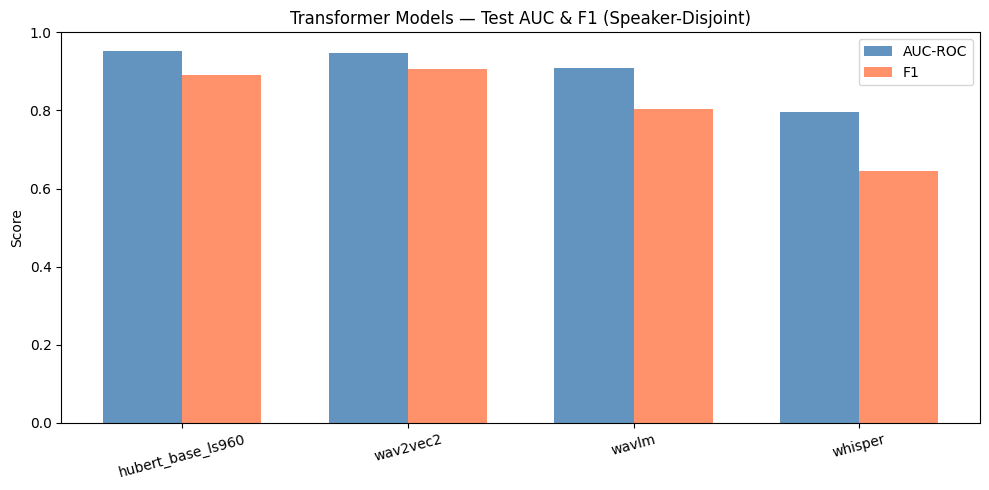

In [11]:
if trans_results is None:
    raise FileNotFoundError("Run: python scripts/train_transformers.py")

# Comparison bar chart: AUC-ROC and F1 per model
models = list(trans_results.keys())
aucs = [trans_results[m]["auc_roc"] for m in models]
f1s = [trans_results[m]["f1"] for m in models]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, aucs, width, label="AUC-ROC", color="steelblue", alpha=0.85)
ax.bar(x + width/2, f1s, width, label="F1", color="coral", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Transformer Models — Test AUC & F1 (Speaker-Disjoint)")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Metrics comparison table
import pandas as pd
rows = []
for name, m in trans_results.items():
    rows.append({
        "Model": name,
        "Accuracy": m["accuracy"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "AUC-ROC": m["auc_roc"],
    })
df_metrics = pd.DataFrame(rows)
df_metrics.round(3)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,hubert_base_ls960,0.869,0.981,0.815,0.891,0.953
1,wav2vec2,0.879,0.933,0.879,0.905,0.946
2,wavlm,0.768,0.900,0.727,0.804,0.910
3,whisper,0.639,0.903,0.502,0.646,0.795


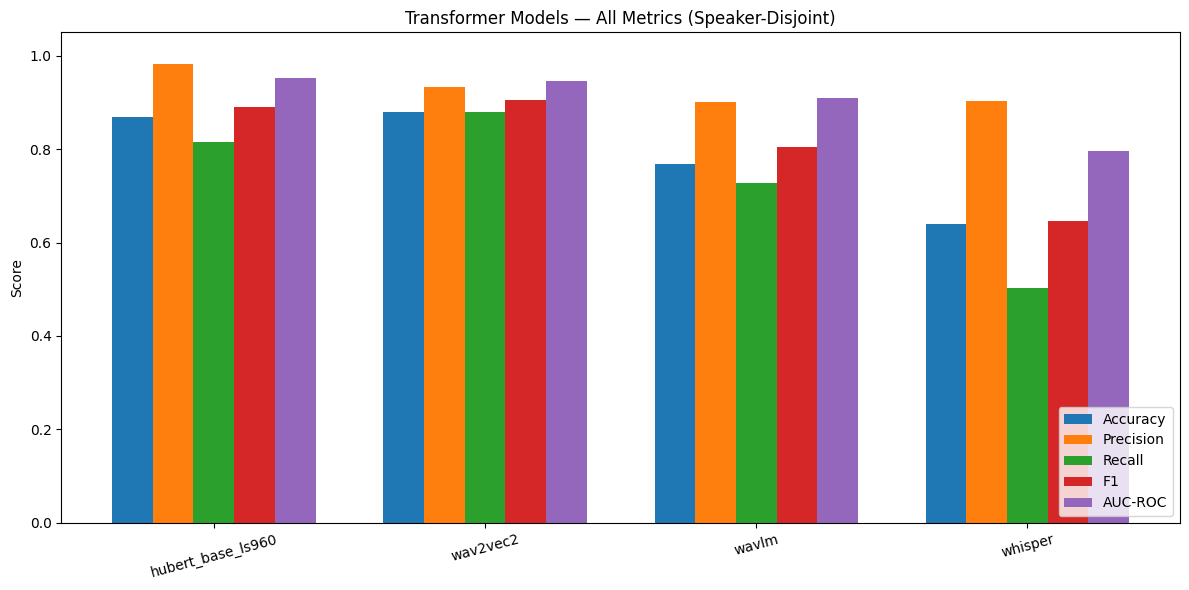

In [13]:
# Grouped bar chart — all metrics per model
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "auc_roc"]
labels = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
x = np.arange(len(trans_results))
width = 0.15
fig, ax = plt.subplots(figsize=(12, 6))
for i, (key, lab) in enumerate(zip(metrics_to_plot, labels)):
    vals = [trans_results[m][key] for m in trans_results]
    offset = (i - 2) * width
    ax.bar(x + offset, vals, width, label=lab)
ax.set_xticks(x)
ax.set_xticklabels(trans_results.keys(), rotation=15)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Transformer Models — All Metrics (Speaker-Disjoint)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

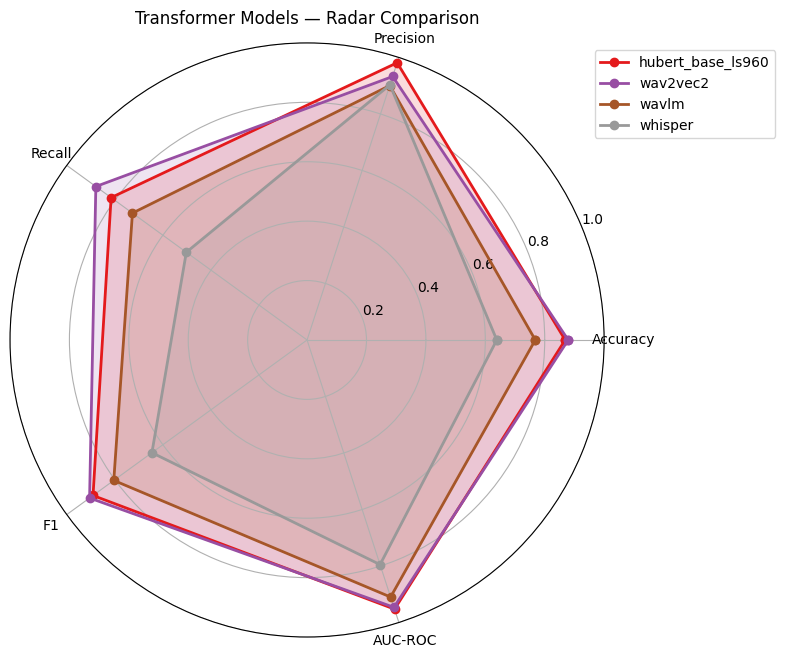

In [14]:
# Radar (spider) chart comparing models
from math import pi
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "auc_roc"]
labels = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
n = len(labels)
angles = [2 * pi * i / n for i in range(n)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.Set1(np.linspace(0, 1, len(trans_results)))
for (name, m), c in zip(trans_results.items(), colors):
    vals = [m[k] for k in metrics_to_plot]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=name, color=c)
    ax.fill(angles, vals, alpha=0.15, color=c)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Transformer Models — Radar Comparison")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

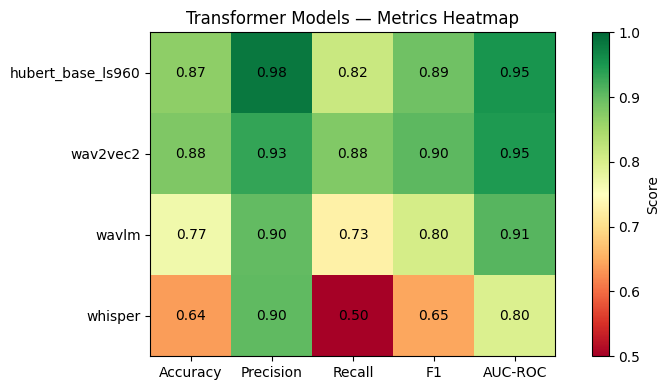

In [15]:
# Heatmap of metrics (models × metrics)
mat = np.array([[trans_results[m][k] for k in metrics_to_plot] for m in trans_results])
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(mat, cmap="RdYlGn", vmin=0.5, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(trans_results)))
ax.set_yticklabels(trans_results.keys())
for i in range(len(trans_results)):
    for j in range(len(labels)):
        ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", color="black", fontsize=10)
plt.colorbar(im, ax=ax, label="Score")
ax.set_title("Transformer Models — Metrics Heatmap")
plt.tight_layout()
plt.show()

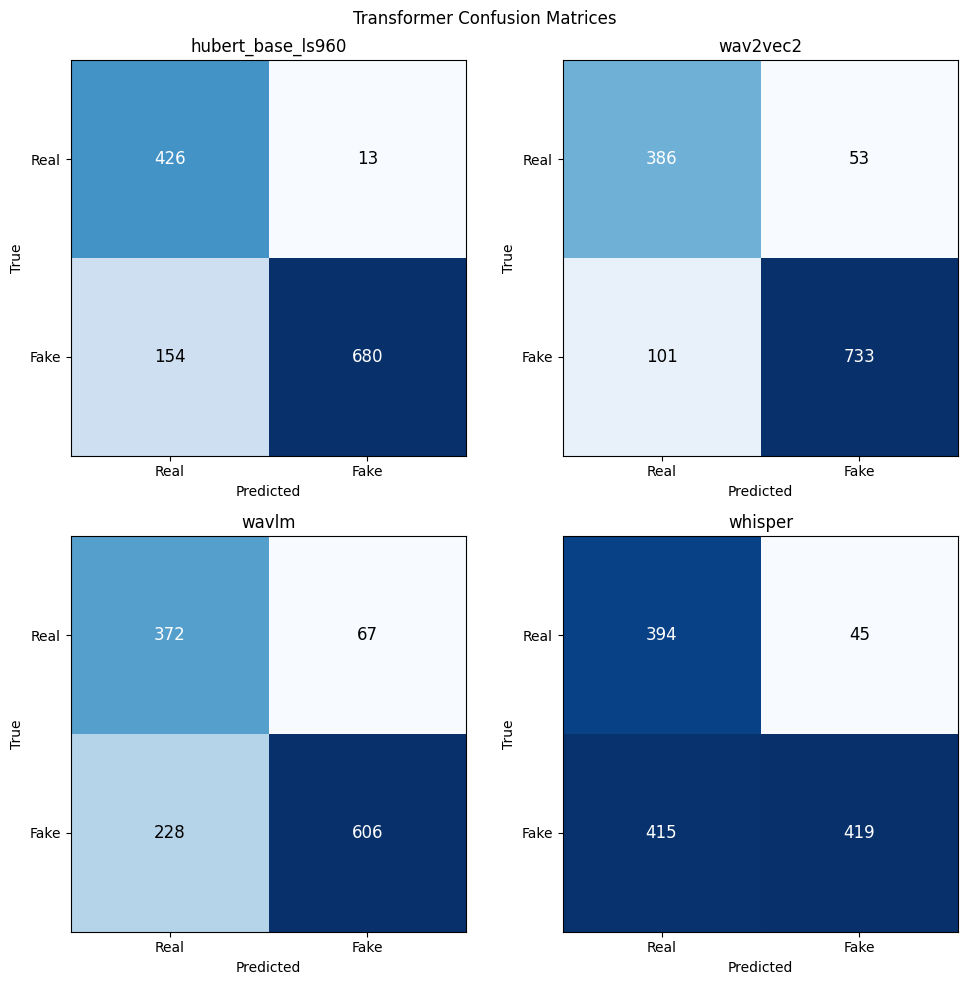

In [16]:
# Confusion matrices (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for idx, (name, m) in enumerate(trans_results.items()):
    ax = axes[idx]
    cm = np.array(m["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Real", "Fake"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Real", "Fake"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            c = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=c, fontsize=12)
plt.suptitle("Transformer Confusion Matrices")
plt.tight_layout()
plt.show()

## Comparison to Earlier Stages

Compare AUC and F1 with Stage 4 (RF, LR) and Stage 5 (CNN). All use speaker-disjoint evaluation for fair comparison.

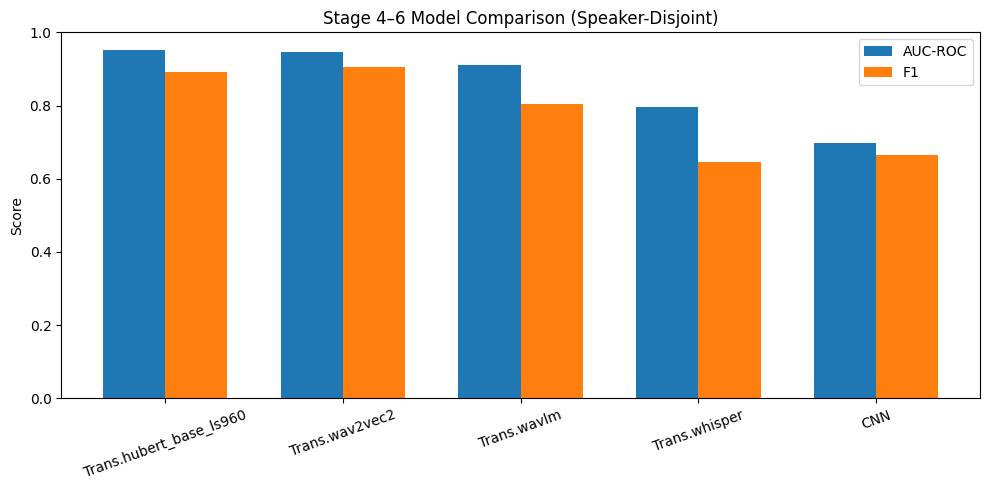

In [17]:
# Load RF/CNN for comparison if available
comparison = []
for name, m in trans_results.items():
    comparison.append((f"Trans.{name}", m["auc_roc"], m["f1"]))

if (OUTPUTS_DIR / "cnn_results.json").exists():
    with open(OUTPUTS_DIR / "cnn_results.json") as f:
        c = json.load(f)
    comparison.append(("CNN", c["auc_roc"], c["f1"]))
if (OUTPUTS_DIR / "baseline_results.json").exists():
    with open(OUTPUTS_DIR / "baseline_results.json") as f:
        bl = json.load(f)
    for k in ("random_forest", "logistic_regression"):
        if k in bl:
            m = bl[k]
            comparison.append((k.replace("_", " ").title(), m["auc_roc"], m["f1"]))

if comparison:
    names, aucs, f1s = zip(*comparison)
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(names))
    width = 0.35
    ax.bar(x - width/2, aucs, width, label="AUC-ROC")
    ax.bar(x + width/2, f1s, width, label="F1")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title("Stage 4–6 Model Comparison (Speaker-Disjoint)")
    ax.legend()
    plt.tight_layout()
    plt.show()